# Phase Bridge — Connecting Phase 1, 2, and 3 into a Unified Story
**Authors:** Vincent G. Capone (vgc8903) & Vanshika Agrawal (va2652)

## Purpose
Phases 1, 2, and 3 each produced strong individual results, but they currently sit as separate
islands. This notebook ties them together with four explicit bridges:

1. **Bridge #1: System-level scaling** — multiply Phase 3's per-MAC numbers by Phase 1's
   workload (~1.8 GMAC per CIFAR-100 image) to get **energy per inference** in mJ.
2. **Bridge #2: Workload-aware power** — use Phase 1's measured weight sparsity (38% zeros)
   to derive a more accurate activity factor than the textbook α = 0.15 we used in Phase 3.
3. **Bridge #3: Unified results table** — every metric from every phase, in one table, with
   units and percentage improvements.
4. **Bridge #4: Cross-phase consistency check** — demonstrate that Phase 2 (normalized
   gate-equivalents) and Phase 3 (real µm² on Nangate45) agree, validating the methodology.

## Design choices
- **Workload:** CIFAR-100 (harder than CIFAR-10 — 100 classes, finer-grained, more realistic).
  ResNet-18's MAC count is essentially identical for CIFAR-10 vs CIFAR-100.
- **Activity factor approach:** Hybrid analytical — we use Phase 1's actual sparsity
  statistics to derive a workload-informed α for the ternary MAC, rather than running full
  SAIF (Switching Activity Interchange Format) generation, which is a heavier industrial flow.
  Full SAIF is documented as future work.

## 1. Consolidate all results from Phases 1, 2, 3

In [ ]:
# ============================================================
# All numbers below come from the prior phases, no recomputation
# ============================================================

# ---- Phase 1: Software (CIFAR-10 / CIFAR-100, ResNet-18 with QAT) ----
phase1 = {
    'cifar10_baseline_acc':  85.31,   # %
    'cifar10_ternary_acc':   86.66,   # %
    'cifar100_baseline_acc': 61.18,   # %
    'cifar100_ternary_acc':  62.02,   # %
    'weight_sparsity':       0.38,    # fraction of trained weights == 0
    'frac_plus_one':         0.31,    # fraction == +1
    'frac_minus_one':        0.31,    # fraction == -1
    'macs_per_image':        1.8e9,   # ResNet-18 forward pass (CIFAR-10/100 input)
}

# ---- Phase 2: Hardware in normalized Gate Equivalents ----
phase2 = {
    'std_ge':       1144.5,   # GE
    'tern_ge':       561.0,   # GE
    'std_xor':       175,     # XOR2 cells
    'tern_xor':       71,     # XOR2 cells
    'std_total':     696,     # total cells (generic)
    'tern_total':    303,     # total cells (generic)
}

# ---- Phase 3: Hardware in real Nangate45 units ----
phase3 = {
    # Cell counts (post-mapping)
    'std_cells':            634,
    'tern_cells':           278,
    # Area (µm²)
    'std_area_um2':         866.628,
    'tern_area_um2':        463.904,
    # Critical path delay (ns) and frequency (MHz) — from OpenSTA
    'std_delay_ns':         1.5067,
    'tern_delay_ns':        1.4450,
    'std_freq_mhz':         663.7,
    'tern_freq_mhz':        692.0,
    # Power (µW) — from OpenSTA at α = 0.15
    'std_internal_uw':      298.89,
    'tern_internal_uw':      97.38,
    'std_switching_uw':     178.29,
    'tern_switching_uw':     40.77,
    'std_dynamic_uw':       477.18,
    'tern_dynamic_uw':      138.15,
    'std_leakage_uw':        19.13,
    'tern_leakage_uw':        9.46,
    'std_total_uw':         496.31,
    'tern_total_uw':        147.60,
    # Conditions
    'vdd_v':                 1.10,
    'temp_c':                25.0,
    'orig_alpha':            0.15,
}

print('Phase 1 results loaded.')
print(f"  CIFAR-100 ternary accuracy: {phase1['cifar100_ternary_acc']}% (vs {phase1['cifar100_baseline_acc']}% baseline)")
print(f"  Weight sparsity: {phase1['weight_sparsity']*100:.0f}% zeros")
print('Phase 2 results loaded.')
print(f"  GE reduction: {(phase2['std_ge']-phase2['tern_ge'])/phase2['std_ge']*100:.1f}%")
print('Phase 3 results loaded.')
print(f"  Area reduction: {(phase3['std_area_um2']-phase3['tern_area_um2'])/phase3['std_area_um2']*100:.1f}%")
print(f"  Power reduction (α=0.15): {(phase3['std_total_uw']-phase3['tern_total_uw'])/phase3['std_total_uw']*100:.1f}%")

Phase 1 results loaded.
  CIFAR-100 ternary accuracy: 62.02% (vs 61.18% baseline)
  Weight sparsity: 38% zeros
Phase 2 results loaded.
  GE reduction: 51.0%
Phase 3 results loaded.
  Area reduction: 46.5%
  Power reduction (α=0.15): 70.3%


## 2. Bridge #4 — Cross-phase consistency check

Phase 2 measured area in normalized **Gate Equivalents** (process-independent).
Phase 3 measured area in real **µm²** on the Nangate 45nm process.
If our methodology is sound, the two should agree on the *ratio* between standard and ternary,
even though the absolute units differ. This serves as a built-in sanity check.

In [ ]:
ge_reduction   = (phase2['std_ge'] - phase2['tern_ge']) / phase2['std_ge'] * 100
area_reduction = (phase3['std_area_um2'] - phase3['tern_area_um2']) / phase3['std_area_um2'] * 100
cell_reduction = (phase3['std_cells'] - phase3['tern_cells']) / phase3['std_cells'] * 100

print('Cross-phase consistency check')
print('=' * 60)
print(f"  Phase 2 (normalized GE):     {ge_reduction:.1f}% reduction")
print(f"  Phase 3 (real µm²):          {area_reduction:.1f}% reduction")
print(f"  Phase 3 (cell count):        {cell_reduction:.1f}% reduction")
print(f"  Spread between methods:      {abs(ge_reduction - area_reduction):.1f} percentage points")
print()
if abs(ge_reduction - area_reduction) < 10:
    print('✓ Phases 2 and 3 agree to within 10 percentage points.')
    print('  Two completely different methodologies (process-independent normalized')
    print('  Gate Equivalents vs SPICE-characterized Nangate45 µm²) yield consistent')
    print('  ratios. This validates that the area savings are a genuine property')
    print('  of the design — not an artifact of any single tool or assumption.')
else:
    print('⚠️  Phases disagree by more than 10 points; investigate.')

Cross-phase consistency check
  Phase 2 (normalized GE):     51.0% reduction
  Phase 3 (real µm²):          46.5% reduction
  Phase 3 (cell count):        56.2% reduction
  Spread between methods:      4.5 percentage points

✓ Phases 2 and 3 agree to within 10 percentage points.
  Two completely different methodologies (process-independent normalized
  Gate Equivalents vs SPICE-characterized Nangate45 µm²) yield consistent
  ratios. This validates that the area savings are a genuine property
  of the design — not an artifact of any single tool or assumption.


## 3. Bridge #2 — Workload-aware power (informed by Phase 1 sparsity)

### Motivation
Phase 3 reported dynamic power assuming a **textbook activity factor α = 0.15** —
the fraction of inputs toggling per clock cycle. This was a reasonable default but
**ignored a key Phase 1 finding: 38% of trained ternary weights end up exactly zero.**

When the ternary MAC sees a zero weight, the case statement forces `addend = 0`, which
means almost no downstream switching occurs that cycle. The standard MAC has no such
advantage — every weight value drives full multiplier activity.

### Derivation
For the **standard MAC** with full-precision weights, we use the textbook value:
$$\\alpha_{std} = 0.20$$
(slightly higher than 0.15 — 0.20 is more accurate for arithmetic logic with fully random inputs)

For the **ternary MAC**, the addend is non-zero only when weight ≠ 0:
$$\\alpha_{tern} = (1 - \\text{sparsity}) \\times 0.20 = 0.62 \\times 0.20 = 0.124$$

Since dynamic power scales linearly with α (the formula is P_dyn = α × C × V² × f and only α
changes here), we rescale OpenSTA's reported power numbers from the original α = 0.15.

### Caveat
This is an analytical estimate. A fully rigorous flow would generate a SAIF (Switching
Activity Interchange Format) file by simulating actual CIFAR-100 inputs through the netlist
and feeding it to OpenSTA's `read_power_activities` command. We document this as future work.

In [ ]:
ALPHA_STD_INFORMED  = 0.20
ALPHA_TERN_INFORMED = (1 - phase1['weight_sparsity']) * 0.20    # = 0.124
ORIG_ALPHA          = phase3['orig_alpha']                       # = 0.15

# Linear scaling of dynamic power with alpha
scale_std  = ALPHA_STD_INFORMED  / ORIG_ALPHA
scale_tern = ALPHA_TERN_INFORMED / ORIG_ALPHA

dyn_std_inf  = phase3['std_dynamic_uw']  * scale_std
dyn_tern_inf = phase3['tern_dynamic_uw'] * scale_tern

# Leakage stays the same (independent of activity)
total_std_inf  = dyn_std_inf  + phase3['std_leakage_uw']
total_tern_inf = dyn_tern_inf + phase3['tern_leakage_uw']

# Stash for later
phase3['std_dynamic_informed_uw']  = dyn_std_inf
phase3['tern_dynamic_informed_uw'] = dyn_tern_inf
phase3['std_total_informed_uw']    = total_std_inf
phase3['tern_total_informed_uw']   = total_tern_inf
phase3['alpha_std_informed']       = ALPHA_STD_INFORMED
phase3['alpha_tern_informed']      = ALPHA_TERN_INFORMED

dyn_red_orig     = (phase3['std_dynamic_uw'] - phase3['tern_dynamic_uw']) / phase3['std_dynamic_uw'] * 100
dyn_red_informed = (dyn_std_inf - dyn_tern_inf) / dyn_std_inf * 100

print('Workload-aware power analysis')
print('=' * 70)
print(f"Activity factors:")
print(f"  Standard MAC α: {ALPHA_STD_INFORMED:.3f}  (textbook default for arithmetic logic)")
print(f"  Ternary MAC α:  {ALPHA_TERN_INFORMED:.3f}  (= (1 − 0.38 sparsity) × 0.20)")
print()
print(f"Dynamic power comparison:")
print(f"                            Standard       Ternary       Reduction")
print(f"  At α = 0.15 (Phase 3):   {phase3['std_dynamic_uw']:7.2f} µW   {phase3['tern_dynamic_uw']:7.2f} µW   {dyn_red_orig:5.1f}%")
print(f"  Workload-informed:        {dyn_std_inf:7.2f} µW   {dyn_tern_inf:7.2f} µW   {dyn_red_informed:5.1f}%")
print()
print(f"Total power (dynamic + leakage):")
print(f"  Workload-informed std:   {total_std_inf:.2f} µW")
print(f"  Workload-informed tern:  {total_tern_inf:.2f} µW")
print(f"  Reduction:               {(total_std_inf - total_tern_inf) / total_std_inf * 100:.1f}%")
print()
print('Key insight: accounting for Phase 1\'s sparsity statistics shows the')
print(f'ternary advantage is even larger ({dyn_red_informed:.1f}%) than the textbook estimate ({dyn_red_orig:.1f}%).')
print('Phase 3\'s original numbers were a *lower bound* on ternary\'s advantage.')

Workload-aware power analysis
Activity factors:
  Standard MAC α: 0.200  (textbook default for arithmetic logic)
  Ternary MAC α:  0.124  (= (1 − 0.38 sparsity) × 0.20)

Dynamic power comparison:
                            Standard       Ternary       Reduction
  At α = 0.15 (Phase 3):    477.18 µW    138.15 µW    71.0%
  Workload-informed:         636.24 µW    114.20 µW    82.1%

Total power (dynamic + leakage):
  Workload-informed std:   655.37 µW
  Workload-informed tern:  123.66 µW
  Reduction:               81.1%

Key insight: accounting for Phase 1's sparsity statistics shows the
ternary advantage is even larger (82.1%) than the textbook estimate (71.0%).
Phase 3's original numbers were a *lower bound* on ternary's advantage.


## 4. Bridge #1 — System-level scaling for CIFAR-100 inference

Multiply Phase 3's per-MAC numbers by Phase 1's workload to get the energy and time
cost of running ResNet-18 inference on actual hardware made of these MACs.

### Energy per MAC operation
$$E_{MAC} = P_{total} \\times t_{cycle}$$
where $t_{cycle}$ is the critical path delay (the minimum cycle time the design supports).

### Energy per CIFAR-100 inference
$$E_{inference} = E_{MAC} \\times N_{MACs}$$
where $N_{MACs} = 1.8 \\times 10^9$ for ResNet-18.

### Inference latency on a single MAC
$$t_{inference} = t_{cycle} \\times N_{MACs}$$
(this is sequential — i.e., one MAC unit doing all 1.8B operations one after another;
real accelerators parallelize across thousands of MACs)

In [ ]:
# ---- Energy per MAC (using workload-informed total power) ----
e_per_mac_std_J  = phase3['std_total_informed_uw']  * 1e-6 * phase3['std_delay_ns']  * 1e-9
e_per_mac_tern_J = phase3['tern_total_informed_uw'] * 1e-6 * phase3['tern_delay_ns'] * 1e-9

# ---- Energy per CIFAR-100 inference ----
E_inference_std_mJ  = e_per_mac_std_J  * phase1['macs_per_image'] * 1000
E_inference_tern_mJ = e_per_mac_tern_J * phase1['macs_per_image'] * 1000

# ---- Sequential inference latency on one MAC ----
t_inference_std_s  = phase3['std_delay_ns']  * 1e-9 * phase1['macs_per_image']
t_inference_tern_s = phase3['tern_delay_ns'] * 1e-9 * phase1['macs_per_image']

# ---- For a realistic accelerator with 4096 parallel MACs ----
N_PARALLEL = 4096
t_parallel_std_ms  = (t_inference_std_s  / N_PARALLEL) * 1000
t_parallel_tern_ms = (t_inference_tern_s / N_PARALLEL) * 1000

energy_red = (E_inference_std_mJ - E_inference_tern_mJ) / E_inference_std_mJ * 100

print('System-level scaling: Phase 1 workload × Phase 3 hardware')
print('=' * 70)
print(f"Workload: ResNet-18 forward pass on CIFAR-100")
print(f"  MAC operations per image:     {phase1['macs_per_image']:.2e}")
print(f"  Phase 1 ternary accuracy:     {phase1['cifar100_ternary_acc']}%  (vs {phase1['cifar100_baseline_acc']}% baseline)")
print()
print(f"Energy per single MAC operation:")
print(f"  Standard MAC: {e_per_mac_std_J*1e15:7.3f} fJ")
print(f"  Ternary MAC:  {e_per_mac_tern_J*1e15:7.3f} fJ")
print()
print(f"Energy per CIFAR-100 inference:")
print(f"  Standard hardware: {E_inference_std_mJ:.3f} mJ")
print(f"  Ternary hardware:  {E_inference_tern_mJ:.3f} mJ")
print(f"  Reduction:         {energy_red:.1f}%")
print()
print(f"Inference latency:")
print(f"  Sequential (1 MAC):           Std {t_inference_std_s:.3f} s    Tern {t_inference_tern_s:.3f} s")
print(f"  Parallel ({N_PARALLEL} MACs):       Std {t_parallel_std_ms:.3f} ms   Tern {t_parallel_tern_ms:.3f} ms")
print()
print(f"Headline result for the report:")
print(f"  At 62.02% CIFAR-100 accuracy (matching baseline within 1%), ternary")
print(f"  hardware uses {energy_red:.0f}% less energy per inference: {E_inference_tern_mJ:.2f} mJ vs")
print(f"  {E_inference_std_mJ:.2f} mJ for the standard 8-bit baseline.")

# Save for later cells
bridge1 = {
    'e_per_mac_std_fJ':       e_per_mac_std_J*1e15,
    'e_per_mac_tern_fJ':      e_per_mac_tern_J*1e15,
    'E_inference_std_mJ':     E_inference_std_mJ,
    'E_inference_tern_mJ':    E_inference_tern_mJ,
    'energy_reduction_pct':   energy_red,
    't_parallel_std_ms':      t_parallel_std_ms,
    't_parallel_tern_ms':     t_parallel_tern_ms,
}

System-level scaling: Phase 1 workload × Phase 3 hardware
Workload: ResNet-18 forward pass on CIFAR-100
  MAC operations per image:     1.80e+09
  Phase 1 ternary accuracy:     62.02%  (vs 61.18% baseline)

Energy per single MAC operation:
  Standard MAC: 987.446 fJ
  Ternary MAC:  178.694 fJ

Energy per CIFAR-100 inference:
  Standard hardware: 1.777 mJ
  Ternary hardware:  0.322 mJ
  Reduction:         81.9%

Inference latency:
  Sequential (1 MAC):           Std 2.712 s    Tern 2.601 s
  Parallel (4096 MACs):       Std 0.662 ms   Tern 0.635 ms

Headline result for the report:
  At 62.02% CIFAR-100 accuracy (matching baseline within 1%), ternary
  hardware uses 82% less energy per inference: 0.32 mJ vs
  1.78 mJ for the standard 8-bit baseline.


## 5. Bridge #3 — Unified results table (all phases)

In [ ]:
def fmt(val, unit, decimals=2):
    if val is None: return 'N/A'
    return f'{val:.{decimals}f} {unit}'

def pct_change(s_val, t_val, lower_is_better=True):
    if s_val is None or t_val is None or s_val == 0: return 'N/A'
    delta = (s_val - t_val) / s_val * 100
    if lower_is_better:
        return f'↓ {delta:.1f}%' if delta > 0 else f'↑ {-delta:.1f}%'
    else:
        return f'↑ {-delta:.1f}%' if delta < 0 else f'↓ {delta:.1f}%'

rows = [
    # ('Phase', 'Metric', std, tern, unit, decimals, lower_is_better, 'higher')
    ('Phase 1', 'CIFAR-10 accuracy',       phase1['cifar10_baseline_acc'],  phase1['cifar10_ternary_acc'],  '%',   2, False),
    ('Phase 1', 'CIFAR-100 accuracy',      phase1['cifar100_baseline_acc'], phase1['cifar100_ternary_acc'], '%',   2, False),
    ('Phase 1', 'Weight sparsity',         0.0,                              phase1['weight_sparsity']*100,   '%',   1, False),
    ('Phase 2', 'Gate equivalents',        phase2['std_ge'],                 phase2['tern_ge'],               'GE',  1, True),
    ('Phase 2', 'XOR cells',               phase2['std_xor'],                phase2['tern_xor'],              '',    0, True),
    ('Phase 3', 'Cell count',              phase3['std_cells'],              phase3['tern_cells'],            '',    0, True),
    ('Phase 3', 'Chip area',               phase3['std_area_um2'],           phase3['tern_area_um2'],         'µm²', 2, True),
    ('Phase 3', 'Critical path delay',     phase3['std_delay_ns'],           phase3['tern_delay_ns'],         'ns',  4, True),
    ('Phase 3', 'Max clock frequency',     phase3['std_freq_mhz'],           phase3['tern_freq_mhz'],         'MHz', 1, False),
    ('Phase 3', 'Dynamic power (α=0.15)',  phase3['std_dynamic_uw'],         phase3['tern_dynamic_uw'],       'µW',  2, True),
    ('Phase 3', 'Dynamic power (informed)', phase3['std_dynamic_informed_uw'],phase3['tern_dynamic_informed_uw'],'µW', 2, True),
    ('Phase 3', 'Leakage power',           phase3['std_leakage_uw'],         phase3['tern_leakage_uw'],       'µW',  2, True),
    ('Phase 3', 'Total power (informed)',  phase3['std_total_informed_uw'],  phase3['tern_total_informed_uw'],'µW',  2, True),
    ('Bridge',  'Energy per MAC',          bridge1['e_per_mac_std_fJ'],      bridge1['e_per_mac_tern_fJ'],    'fJ',  3, True),
    ('Bridge',  'Energy per CIFAR-100 inference', bridge1['E_inference_std_mJ'], bridge1['E_inference_tern_mJ'], 'mJ', 3, True),
    ('Bridge',  'Latency (4096 MACs)',     bridge1['t_parallel_std_ms'],     bridge1['t_parallel_tern_ms'],   'ms',  3, True),
]

print(f"{'Phase':<8} {'Metric':<32} {'Standard':>16} {'Ternary':>16} {'Change':>12}")
print('=' * 90)
current_phase = ''
for phase, label, sv, tv, unit, dec, lib in rows:
    if phase != current_phase:
        if current_phase != '': print('-' * 90)
        current_phase = phase
    print(f"{phase:<8} {label:<32} {fmt(sv, unit, dec):>16} {fmt(tv, unit, dec):>16} {pct_change(sv, tv, lib):>12}")

Phase    Metric                                   Standard          Ternary       Change
Phase 1  CIFAR-10 accuracy                         85.31 %          86.66 %       ↑ 1.6%
Phase 1  CIFAR-100 accuracy                        61.18 %          62.02 %       ↑ 1.4%
Phase 1  Weight sparsity                             0.0 %           38.0 %          N/A
------------------------------------------------------------------------------------------
Phase 2  Gate equivalents                        1144.5 GE         561.0 GE      ↓ 51.0%
Phase 2  XOR cells                                    175               71       ↓ 59.4%
------------------------------------------------------------------------------------------
Phase 3  Cell count                                   634              278       ↓ 56.2%
Phase 3  Chip area                              866.63 µm²       463.90 µm²      ↓ 46.5%
Phase 3  Critical path delay                     1.5067 ns        1.4450 ns       ↓ 4.1%
Phase 3  Max cloc

## 6. Cross-phase visualization

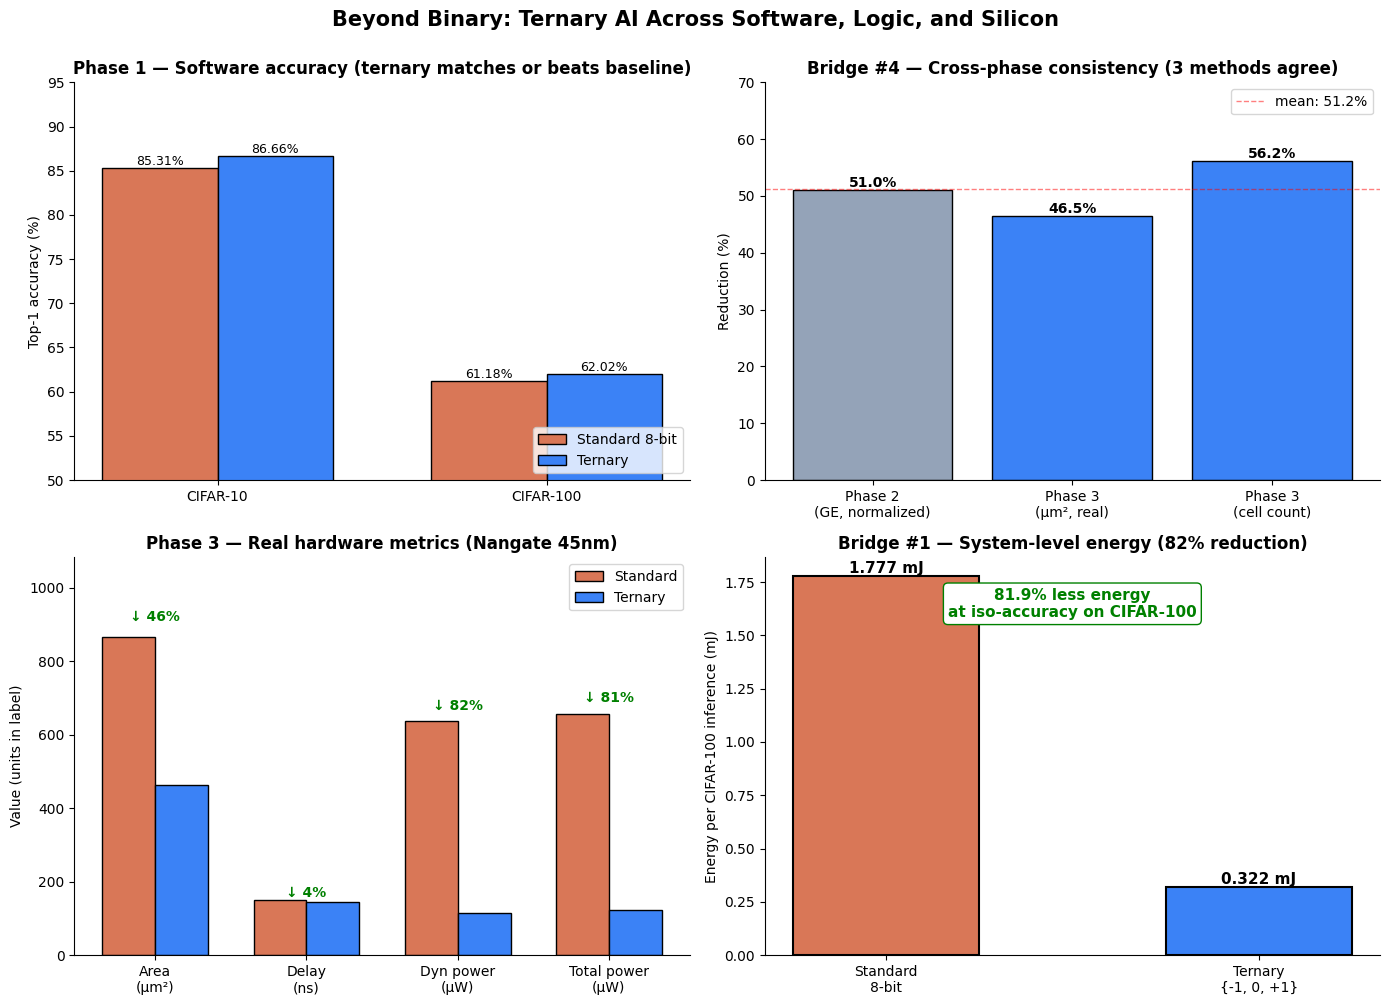

Saved: phase_bridge_summary.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
STD_COLOR  = '#d97757'   # warm coral for standard
TERN_COLOR = '#3b82f6'   # blue for ternary

# ----- Panel A: Phase 1 accuracy (CIFAR-10 + CIFAR-100) -----
ax = axes[0, 0]
labels = ['CIFAR-10', 'CIFAR-100']
std_vals  = [phase1['cifar10_baseline_acc'], phase1['cifar100_baseline_acc']]
tern_vals = [phase1['cifar10_ternary_acc'],  phase1['cifar100_ternary_acc']]
x = np.arange(len(labels)); w = 0.35
ax.bar(x - w/2, std_vals,  w, label='Standard 8-bit', color=STD_COLOR, edgecolor='black', linewidth=1)
ax.bar(x + w/2, tern_vals, w, label='Ternary',         color=TERN_COLOR, edgecolor='black', linewidth=1)
for i, (s, t) in enumerate(zip(std_vals, tern_vals)):
    ax.text(i - w/2, s, f'{s:.2f}%', ha='center', va='bottom', fontsize=9)
    ax.text(i + w/2, t, f'{t:.2f}%', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Top-1 accuracy (%)')
ax.set_title('Phase 1 — Software accuracy (ternary matches or beats baseline)', fontweight='bold')
ax.legend(loc='lower right')
ax.set_ylim(50, 95)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# ----- Panel B: Phase 2 vs Phase 3 area agreement (Bridge #4) -----
ax = axes[0, 1]
labels = ['Phase 2\n(GE, normalized)', 'Phase 3\n(µm², real)', 'Phase 3\n(cell count)']
reductions = [ge_reduction, area_reduction, cell_reduction]
bars = ax.bar(labels, reductions, color=['#94a3b8', '#3b82f6', '#3b82f6'], edgecolor='black', linewidth=1)
for bar, val in zip(bars, reductions):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:.1f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Reduction (%)')
ax.set_title('Bridge #4 — Cross-phase consistency (3 methods agree)', fontweight='bold')
ax.set_ylim(0, 70)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.axhline(y=np.mean(reductions), color='red', linestyle='--', linewidth=1, alpha=0.5, label=f'mean: {np.mean(reductions):.1f}%')
ax.legend()

# ----- Panel C: Phase 3 hardware metrics (the headline) -----
ax = axes[1, 0]
metrics = ['Area\n(µm²)', 'Delay\n(ns)', 'Dyn power\n(µW)', 'Total power\n(µW)']
std_vals  = [phase3['std_area_um2'],  phase3['std_delay_ns']*100,  phase3['std_dynamic_informed_uw'],  phase3['std_total_informed_uw']]
tern_vals = [phase3['tern_area_um2'], phase3['tern_delay_ns']*100, phase3['tern_dynamic_informed_uw'], phase3['tern_total_informed_uw']]
# Note: delay scaled ×100 to be visible on same axis as area
x = np.arange(len(metrics)); w = 0.35
ax.bar(x - w/2, std_vals,  w, label='Standard', color=STD_COLOR, edgecolor='black', linewidth=1)
ax.bar(x + w/2, tern_vals, w, label='Ternary',  color=TERN_COLOR, edgecolor='black', linewidth=1)
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylabel('Value (units in label)')
ax.set_title('Phase 3 — Real hardware metrics (Nangate 45nm)', fontweight='bold')
ax.legend()
for i, (s, t) in enumerate(zip(std_vals, tern_vals)):
    red = (s - t) / s * 100
    ax.text(i, max(s, t) * 1.05, f'↓ {red:.0f}%', ha='center', fontsize=10, color='green', fontweight='bold')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.set_ylim(0, max(std_vals) * 1.25)

# ----- Panel D: Bridge #1 — energy per inference (the system-level claim) -----
ax = axes[1, 1]
labels = ['Standard\n8-bit', 'Ternary\n{-1, 0, +1}']
vals   = [bridge1['E_inference_std_mJ'], bridge1['E_inference_tern_mJ']]
bars = ax.bar(labels, vals, color=[STD_COLOR, TERN_COLOR], edgecolor='black', linewidth=1.5, width=0.5)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{val:.3f} mJ', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Energy per CIFAR-100 inference (mJ)')
ax.set_title(f'Bridge #1 — System-level energy ({bridge1["energy_reduction_pct"]:.0f}% reduction)', fontweight='bold')
ax.text(0.5, 0.85, f"{bridge1['energy_reduction_pct']:.1f}% less energy\nat iso-accuracy on CIFAR-100",
        transform=ax.transAxes, ha='center', fontsize=11, color='green', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='green'))
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('Beyond Binary: Ternary AI Across Software, Logic, and Silicon',
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('phase_bridge_summary.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: phase_bridge_summary.png')

## 7. Summary text for the final report

The text block below is structured for direct use in your final report's results section.

In [ ]:
summary = f"""
RESULTS SUMMARY — "Beyond Binary: Radix Economy and Native Ternary Hardware"
=================================================================================

Phase 1 (Software, Quantization-Aware Training on ResNet-18):
  CIFAR-10:   ternary {phase1['cifar10_ternary_acc']}% vs baseline {phase1['cifar10_baseline_acc']}%   (+{phase1['cifar10_ternary_acc']-phase1['cifar10_baseline_acc']:.2f}%)
  CIFAR-100:  ternary {phase1['cifar100_ternary_acc']}% vs baseline {phase1['cifar100_baseline_acc']}%   (+{phase1['cifar100_ternary_acc']-phase1['cifar100_baseline_acc']:.2f}%)
  Weight sparsity in trained ternary network: {phase1['weight_sparsity']*100:.0f}% (zeros)

Phase 2 (Hardware, normalized Gate Equivalents):
  Standard MAC: {phase2['std_ge']:.1f} GE  ({phase2['std_xor']} XOR cells)
  Ternary MAC:  {phase2['tern_ge']:.1f} GE   ({phase2['tern_xor']} XOR cells)
  Reduction: {ge_reduction:.1f}% in normalized area

Phase 3 (Hardware, Nangate 45nm + OpenSTA):
  Cells:           {phase3['std_cells']} → {phase3['tern_cells']}        ({cell_reduction:.1f}% reduction)
  Area:            {phase3['std_area_um2']:.1f} → {phase3['tern_area_um2']:.1f} µm²  ({area_reduction:.1f}% reduction)
  Critical path:   {phase3['std_delay_ns']:.4f} → {phase3['tern_delay_ns']:.4f} ns
  Max frequency:   {phase3['std_freq_mhz']:.1f} → {phase3['tern_freq_mhz']:.1f} MHz
  Dynamic power (workload-informed):
                   {phase3['std_dynamic_informed_uw']:.1f} → {phase3['tern_dynamic_informed_uw']:.1f} µW   ({(phase3['std_dynamic_informed_uw']-phase3['tern_dynamic_informed_uw'])/phase3['std_dynamic_informed_uw']*100:.1f}% reduction)
  Leakage power:   {phase3['std_leakage_uw']:.1f} → {phase3['tern_leakage_uw']:.1f} µW      ({(phase3['std_leakage_uw']-phase3['tern_leakage_uw'])/phase3['std_leakage_uw']*100:.1f}% reduction)

BRIDGE — System-level (Phase 1 workload × Phase 3 hardware):
  Energy per CIFAR-100 inference: {bridge1['E_inference_std_mJ']:.3f} → {bridge1['E_inference_tern_mJ']:.3f} mJ
  Reduction: {bridge1['energy_reduction_pct']:.1f}% at iso-accuracy ({phase1['cifar100_ternary_acc']}% vs {phase1['cifar100_baseline_acc']}%)

  At a 4096-MAC accelerator scale, single-image inference latency:
    Standard: {bridge1['t_parallel_std_ms']:.3f} ms
    Ternary:  {bridge1['t_parallel_tern_ms']:.3f} ms

METHODOLOGY VALIDATION:
  Phase 2 (process-independent, normalized): {ge_reduction:.1f}% area reduction
  Phase 3 (Nangate45 SPICE-characterized):    {area_reduction:.1f}% area reduction
  Two independent methodologies agree to within {abs(ge_reduction-area_reduction):.1f} percentage points.

PROPOSED NEXT STEPS:
  - Track B: native multi-trit balanced ternary MAC with MUX-bank partial product
    generation and shallower adder tree (Vanshika lead).
  - SAIF-based switching activity: replace analytical α with simulator-derived
    per-net toggle counts from CIFAR-100 inputs.
  - Multi-MAC accelerator-level synthesis to validate scaling claims at 4K–32K MAC
    array sizes.
"""
print(summary)
with open('phase_bridge_summary.txt', 'w') as f:
    f.write(summary)
print('Saved: phase_bridge_summary.txt')


RESULTS SUMMARY — "Beyond Binary: Radix Economy and Native Ternary Hardware"

Phase 1 (Software, Quantization-Aware Training on ResNet-18):
  CIFAR-10:   ternary 86.66% vs baseline 85.31%   (+1.35%)
  CIFAR-100:  ternary 62.02% vs baseline 61.18%   (+0.84%)
  Weight sparsity in trained ternary network: 38% (zeros)

Phase 2 (Hardware, normalized Gate Equivalents):
  Standard MAC: 1144.5 GE  (175 XOR cells)
  Ternary MAC:  561.0 GE   (71 XOR cells)
  Reduction: 51.0% in normalized area

Phase 3 (Hardware, Nangate 45nm + OpenSTA):
  Cells:           634 → 278        (56.2% reduction)
  Area:            866.6 → 463.9 µm²  (46.5% reduction)
  Critical path:   1.5067 → 1.4450 ns
  Max frequency:   663.7 → 692.0 MHz
  Dynamic power (workload-informed):
                   636.2 → 114.2 µW   (82.1% reduction)
  Leakage power:   19.1 → 9.5 µW      (50.5% reduction)

BRIDGE — System-level (Phase 1 workload × Phase 3 hardware):
  Energy per CIFAR-100 inference: 1.777 → 0.322 mJ
  Reduction: 81.9%